<a href="https://colab.research.google.com/github/sahuabinash/pub_2025_aiml/blob/master/SLM_from_scratch_12M_params.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [ ]:
!pip install -q datasets tokenizers

In [ ]:
import math, os, time, random
from dataclasses import dataclass
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

if device == 'cuda' and torch.cuda.is_bf16_supported():
    autocast_dtype = torch.bfloat16
elif device == 'cuda':
    autocast_dtype = torch.float16
else:
    autocast_dtype = torch.float32

print(f'device: {device} | autocase dtype: {autocast_dtype}')
# video output: device: cuda | autocase dtype: torch.bfloat16
# ("autocase" typo kept as in the video)

device: cuda | autocase dtype: torch.bfloat16


## Streaming the dataset from HF

In [ ]:
from datasets import load_dataset

N_STORIES = 150_000
EOT = '<|eot|>'

stream = load_dataset('roneneldan/TinyStories', split = 'train', streaming = True)
stories = []

t0 = time.time()
for item in stream:
    s = item['text'].strip()

    if s:
        stories.append(s)
    if len(stories) >= N_STORIES:
        break
    if len(stories) % 25000 == 0:
        print(f'{len(stories):,} stories . {time.time()-t0:.0f}s')

n_chars = sum(len(s) for s in stories)
print(n_chars)
# video output: progress lines every 25,000 stories, then 134183106 (~134M characters)

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

25,000 stories . 12s
50,000 stories . 14s
75,000 stories . 16s
100,000 stories . 18s
125,000 stories . 20s
134103106


## Tokenizer training

In [ ]:
from tokenizers import Tokenizer, models, pre_tokenizers, decoders, trainers

VOCAB_SIZE = 4096

tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space = False)
tokenizer.decoder = decoders.ByteLevel()
trainer = trainers.BpeTrainer(
    vocab_size = VOCAB_SIZE,
    special_tokens = [EOT],
    initial_alphabet = pre_tokenizers.ByteLevel.alphabet(),
)
tokenizer.train_from_iterator(stories, trainer)
print(tokenizer.get_vocab_size())
# video output: 4096

4096


In [ ]:
EOT_ID = tokenizer.token_to_id(EOT)
print(EOT_ID)
# video output: 0

0


In [ ]:
ids = []
t0 = time.time()

BATCH = 10000

for i in range(0, len(stories), BATCH):
    for enc in tokenizer.encode_batch(stories[i:i+BATCH]):
        ids.extend(enc.ids)
        ids.append(EOT_ID)

data = np.array(ids, dtype=np.uint16)

n_val = len(data) // 100
train_data, val_data = data[:-n_val], data[-n_val:]
print(len(train_data), len(val_data))

33896558 342389


In [ ]:
print(len(train_data)/1000000, len(val_data)/1000000)

33.896558 0.342389


In [ ]:
print(n_chars/len(data))

3.9166831269664923


In [ ]:
BLOCK_SIZE = 256
BATCH_SIZE = 32

def get_batch(split: str):
    arr = train_data if split == 'train' else val_data
    ix = torch.randint(len(arr) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([torch.from_numpy(arr[i:i+BLOCK_SIZE].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(arr[i+1:i+1+BLOCK_SIZE].astype(np.int64)) for i in ix])
    if device == 'cuda':
        return (x.pin_memory().to(device, non_blocking=True),
                y.pin_memory().to(device, non_blocking=True))
    return x.to(device), y.to(device)

x, y = get_batch('train')
print('x:', tuple(x.shape), '· y:', tuple(y.shape))
print(x[0, :8].tolist())
print(y[0, :8].tolist())

x: (32, 256) · y: (32, 256)
[199, 2, 1210, 364, 483, 349, 1290, 263]
[2, 1210, 364, 483, 349, 1290, 263, 1182]


## Mini-GPT style model

In [ ]:
@dataclass(frozen=True)
class MiniGPTConfig:
    vocab_size: int = VOCAB_SIZE
    block_size: int = BLOCK_SIZE
    n_layer: int = 6
    d_model: int = 384
    n_head: int = 6

class CausalSelfAttention(nn.Module):
    def __init__(self, config: MiniGPTConfig):
        super().__init__()
        self.n_head = config.n_head
        self.qkv = nn.Linear(config.d_model, 3 * config.d_model, bias = False)
        self.proj = nn.Linear(config.d_model, config.d_model, bias = False)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim = 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        out = F.scaled_dot_product_attention(q, k, v, is_causal = True)
        return self.proj(out.transpose(1, 2).reshape(B, T, C))

class Block(nn.Module):
    def __init__(self, config: MiniGPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.d_model)
        self.attn = CausalSelfAttention(config)
        self.ln2 = nn.LayerNorm(config.d_model)
        self.mlp = nn.Sequential(
            nn.Linear(config.d_model, 4 * config.d_model, bias = False),
            nn.GELU(),
            nn.Linear(4 * config.d_model, config.d_model, bias = False),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.mlp(self.ln2(x))

class MiniGPT(nn.Module):
    def __init__(self, config: MiniGPTConfig):
        super().__init__()
        self.config = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.d_model)
        self.pos_emb = nn.Embedding(config.block_size, config.d_model)   # [BUG, see notes: should be config.block_size]
        self.blocks = nn.ModuleList(Block(config) for _ in range(config.n_layer))
        self.ln_final = nn.LayerNorm(config.d_model)
        self.lm_head = nn.Linear(config.d_model, config.vocab_size, bias = False)
        self.lm_head.weight = self.tok_emb.weight   # [see notes: missing from the version the video actually ran]
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean = 0.0, std = 0.02)

    def forward(self, idx):
        B, T = idx.shape
        pos = torch.arange(T, device = idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        for block in self.blocks:
            x = block(x)
        return self.lm_head(self.ln_final(x))

In [ ]:
model = MiniGPT(MiniGPTConfig()).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(n_params/1000000)

12.297984


# LR scheduling and optimizer

In [ ]:
MAX_STEPS    = 2500
ACCUM        = 2                      # micro-steps per optimizer step
LR           = 6e-4
MIN_LR       = 6e-5
WARMUP_STEPS = 100
GRAD_CLIP    = 1.0
EVAL_EVERY   = 250
EVAL_BATCHES = 40
LOG_EVERY    = 50
TOKENS_PER_STEP = BATCH_SIZE * BLOCK_SIZE * ACCUM
print(f'{TOKENS_PER_STEP:,} tokens/step · {MAX_STEPS*TOKENS_PER_STEP/1e6:.0f}M tokens total')

def build_optimizer(model, lr, weight_decay=0.1):
    decay    = [p for p in model.parameters() if p.requires_grad and p.dim() >= 2]
    no_decay = [p for p in model.parameters() if p.requires_grad and p.dim() < 2]
    groups = [
        {'params': decay, 'weight_decay': weight_decay},
        {'params': no_decay, 'weight_decay': 0.0},
    ]
    return torch.optim.AdamW(groups, lr=lr, betas=(0.9, 0.95), eps=1e-8)

def lr_for_step(step):
    if step < WARMUP_STEPS:
        return LR * (step + 1) / WARMUP_STEPS
    frac = (step - WARMUP_STEPS) / max(1, MAX_STEPS - WARMUP_STEPS)
    coeff = 0.5 * (1.0 + math.cos(math.pi * min(frac, 1.0)))
    return MIN_LR + coeff * (LR - MIN_LR)

optimizer = build_optimizer(model, LR)
scaler = torch.amp.GradScaler(device, enabled=(autocast_dtype == torch.float16))
print(f'optimizer ready · GradScaler enabled: {scaler.is_enabled()}')


16,384 tokens/step · 41M tokens total
optimizer ready · GradScaler enabled: False


## Training loop

In [ ]:
@torch.no_grad()
def estimate_val_loss():
    model.eval()
    total = 0.0
    for _ in range(EVAL_BATCHES):
        x, y = get_batch('val')
        with torch.autocast(device_type=device, dtype=autocast_dtype, enabled=(device == 'cuda')):
            logits = model(x)
            total += F.cross_entropy(logits.view(-1, logits.size(-1)), y.reshape(-1)).item()
    model.train()
    return total / EVAL_BATCHES

history = {'step': [], 'loss': [], 'val_step': [], 'val_loss': []}
model.train()
t0 = time.time()

for step in range(1, MAX_STEPS + 1):
    lr = lr_for_step(step)                       # (1) schedule
    for g in optimizer.param_groups:
        g['lr'] = lr

    optimizer.zero_grad(set_to_none=True)
    loss_accum = 0.0
    for _ in range(ACCUM):                       # (2) accumulate
        x, y = get_batch('train')
        with torch.autocast(device_type=device, dtype=autocast_dtype, enabled=(device == 'cuda')):
            logits = model(x)                                        # (B, T, vocab)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                   y.reshape(-1)) / ACCUM
        scaler.scale(loss).backward()            # adds into p.grad
        loss_accum += loss.item()

    scaler.unscale_(optimizer)                   # so clipping sees true gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)   # (3) clip
    scaler.step(optimizer)                       # (4) AdamW update
    scaler.update()

    if step % LOG_EVERY == 0 or step == 1:
        tps = step * TOKENS_PER_STEP / (time.time() - t0)
        history['step'].append(step); history['loss'].append(loss_accum)
        print(f'step {step:5d}/{MAX_STEPS} · loss {loss_accum:.4f} · lr {lr:.2e} · {tps:,.0f} tok/s')

    if step % EVAL_EVERY == 0:                   # (5) validation
        vl = estimate_val_loss()
        history['val_step'].append(step); history['val_loss'].append(vl)
        print(f'  -> val loss {vl:.4f} · val perplexity {math.exp(vl):.1f}')

print(f'done in {(time.time()-t0)/60:.1f} min · '
      f'{MAX_STEPS*TOKENS_PER_STEP/1e6:.0f}M tokens seen')


step     1/2500 · loss 8.3854 · lr 1.20e-05 · 11,019 tok/s
step    50/2500 · loss 5.4718 · lr 3.06e-04 · 28,908 tok/s
step   100/2500 · loss 4.2047 · lr 6.00e-04 · 28,894 tok/s
step   150/2500 · loss 3.7870 · lr 5.99e-04 · 28,594 tok/s
step   200/2500 · loss 3.5696 · lr 5.98e-04 · 28,162 tok/s
step   250/2500 · loss 3.4483 · lr 5.95e-04 · 28,002 tok/s
  -> val loss 3.3401 · val perplexity 28.2
step   300/2500 · loss 3.2104 · lr 5.91e-04 · 27,148 tok/s
step   350/2500 · loss 3.1120 · lr 5.86e-04 · 27,089 tok/s
step   400/2500 · loss 2.9002 · lr 5.79e-04 · 27,077 tok/s
step   450/2500 · loss 2.9081 · lr 5.72e-04 · 27,054 tok/s
step   500/2500 · loss 2.7748 · lr 5.64e-04 · 27,027 tok/s
  -> val loss 2.7470 · val perplexity 15.6
step   550/2500 · loss 2.7579 · lr 5.54e-04 · 26,659 tok/s
step   600/2500 · loss 2.7071 · lr 5.44e-04 · 26,674 tok/s
step   650/2500 · loss 2.6084 · lr 5.33e-04 · 26,690 tok/s
step   700/2500 · loss 2.5120 · lr 5.21e-04 · 26,704 tok/s
step   750/2500 · loss 2.5113

Loss plot

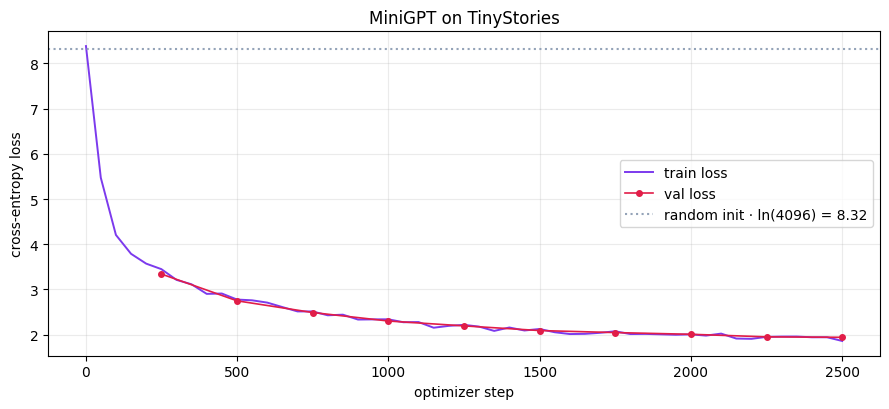

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(history['step'], history['loss'], lw=1.4, color='#7c3aed', label='train loss')
ax.plot(history['val_step'], history['val_loss'], 'o-', ms=4, lw=1.2,
        color='#e11d48', label='val loss')
ax.axhline(math.log(VOCAB_SIZE), ls=':', color='#94a3b8',
           label=f'random init · ln({VOCAB_SIZE}) = {math.log(VOCAB_SIZE):.2f}')
ax.set_xlabel('optimizer step'); ax.set_ylabel('cross-entropy loss')
ax.set_title('MiniGPT on TinyStories')
ax.legend(); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()


Inference

In [ ]:
@torch.no_grad()
def generate(prompt: str, max_new_tokens: int = 220, temperature: float = 0.8, top_k: int = 50):
    model.eval()
    idx = torch.tensor([tokenizer.encode(prompt).ids], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        ctx = idx[:, -BLOCK_SIZE:]                     # crop to the context window
        with torch.autocast(device_type=device, dtype=autocast_dtype, enabled=(device == 'cuda')):
            logits = model(ctx)[:, -1, :] / temperature
        v, _ = torch.topk(logits, top_k)
        logits[logits < v[:, [-1]]] = -float('inf')    # keep only the top-k tokens
        next_id = torch.multinomial(F.softmax(logits.float(), dim=-1), num_samples=1)
        if next_id.item() == EOT_ID:
            break
        idx = torch.cat([idx, next_id], dim=1)
    model.train()
    return tokenizer.decode(idx[0].tolist())

for prompt in ['There were two kittens. One happy and one sad.']:
    print('=' * 70)
    print(generate(prompt))


There were two kittens. One happy and one sad. The kittens jumped in the kittens and chased the kittens. They ran, chased after the kittens, and the kittens chased each other. Then, they had to do something else.

The kittens followed the kittens, and they were happy. They ran, jumped, and had fun. But then, the kittens still chased each other, and the kittens were happy again. They thanked the kittens for the delicious day and went home.


In [ ]:
os.makedirs('out', exist_ok=True)
torch.save({'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'step': MAX_STEPS}, 'out/tinygpt.pt')
tokenizer.save('out/tokenizer.json')
size_mb = os.path.getsize('out/tinygpt.pt') / 1e6
print(f'saved out/tinygpt.pt ({size_mb:.0f} MB: weights + AdamW m,v) and out/tokenizer.json')


saved out/tinygpt.pt (148 MB: weights + AdamW m,v) and out/tokenizer.json
